# Grafana health -- is the UI of the stack actually serving?

Grafana is the **G** in LGTM and the surface everything else is read through, so its failure mode
is distinctive: when Grafana is sick its own dashboards cannot tell you. This notebook assumes
the stack works and reads Grafana's self-metrics out of Mimir; the companion
[grafana-nomon.ipynb](grafana-nomon.ipynb) is the variant that assumes nothing.

**The load-bearing check is datasource reachability.** For a UI whose whole job is querying the
other components, "can Grafana reach Mimir and Loki" is the analogue of "is the instrument
alive". Everything else here -- serving errors, provisioning drift, plugin health -- is the
checklist from the deployment's own troubleshooting guide
([README-grafana.md](../charts/argocd-applications/templates/README-grafana.md)), which lists
dashboards-not-appearing, datasources-not-appearing, auth failures and plugin errors as the
things that actually go wrong here.

**Thresholds come from the deployed grafana-mixin** (`tanka/environments/grafana-mixin`,
vendored from upstream -- see its `mixin/UPSTREAM.md`): `GrafanaRequestsFailing` fires at >50%
5xx on a handler for 5m, excluding the datasource-proxy and query handlers. The assumptions
cell reports whether that rule is actually loaded in the Mimir ruler, because a threshold
nobody evaluates is not an alert.

**Scope note:** this is a coverage notebook, not an exhaustive failure taxonomy. It surfaces
the signals that exist for the failures this deployment has a troubleshooting entry for.

---

**Using this notebook to debug something? Improve it before you finish.** These notebooks exist
to move knowledge out of one agent's transcript, so a query, threshold or cross-check that turned
out to matter here belongs *in these cells* before the session ends -- not left behind in a chat
log for nobody. The motivating case is
[#656](https://github.com/symmatree/tiles/issues/656): the alloy-singleton crashloop was caught
only because an earlier session had baked its component-health check into `alloy-health.ipynb`,
and the next reader inherited it. See [docs/notebooks.md](../docs/notebooks.md).


In [1]:
mimir_url = "http://mimir-gateway.mimir.svc"   # grafana_* self-metrics land here (#752)
loki_url = "http://loki.loki.svc:3100"        # grafana namespace logs (incl. the sidecars)
tenant = "tiles"                              # X-Scope-OrgID
namespace = "grafana"
job = "grafana"                               # ServiceMonitor relabels the scrape to this

# sourced: grafana-mixin GrafanaRequestsFailing (>50% 5xx on a handler for 5m). The alert
# deliberately excludes the datasource-proxy/query handlers -- a failing datasource is the
# datasource's problem, and it is covered separately by the datasource section below.
requests_failing_pct = 50
failing_exclude_handlers = "/api/datasources/proxy/:id.*|/api/ds/query|/api/tsdb/query"
# chosen: a datasource erroring at all is worth a line, since there are only a handful of them
datasource_error_pct = 1
# chosen, NOT sourced: "a panel that takes this long reads as broken to a person". Calibrated
# against observed behaviour rather than invented -- normal dashboard traffic here sits at a
# 2-3s p99 against Mimir, because a dashboard issues range queries over many series, so a
# threshold near that fires on a healthy system. 10s is well clear of normal and still well
# under Grafana's dataproxy timeout.
latency_p99_warn_s = 10.0

lookback_hours = 24
recent_minutes = 60      # totals hide when something stopped; the recent slice is the cross-check
range_step_s = 300
instr_stale_s = 600      # chosen: Mimir-serving freshness gate
metric_stale_s = 900     # chosen: grafana_* scrape freshness gate
log_lines = 200
capture_file = ""        # replay a saved capture instead of querying
output_dir = ""          # write capture + agent stats here

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path
import nb_capture as nbc

plt.rcParams.update(nbc.MPL_STYLE)
NOTEBOOK = 'grafana-health'
cap = nbc.Capture(replay_file=capture_file, mimir_url=mimir_url, loki_url=loki_url, tenant=tenant,
                  namespace=namespace, job=job, lookback_hours=lookback_hours,
                  recent_minutes=recent_minutes, range_step_s=range_step_s,
                  metric_stale_s=metric_stale_s, requests_failing_pct=requests_failing_pct,
                  failing_exclude_handlers=failing_exclude_handlers)
m = cap.meta
tenant, namespace, job = m['tenant'], m['namespace'], m['job']
lookback_hours, step = m['lookback_hours'], m['range_step_s']
recent_minutes, metric_stale_s = m['recent_minutes'], m['metric_stale_s']
requests_failing_pct = m['requests_failing_pct']
failing_exclude_handlers = m['failing_exclude_handlers']
mm = nbc.Mimir(cap, m['mimir_url'], tenant)
lk = nbc.Loki(cap, m['loki_url'], tenant)
kube = nbc.Kube(cap)
SEL = f'job="{job}", namespace="{namespace}"'
WIN, RECENT = f'{lookback_hours}h', f'{recent_minutes}m'

print(f"mimir: {m['mimir_url']}  loki: {m['loki_url']}  tenant: {tenant}  job: {job}  "
      f"{'REPLAY of ' + cap.run_at if cap.replay else 'live'}")

mimir: http://mimir-gateway.mimir.svc  loki: http://loki.loki.svc:3100  tenant: tiles  job: grafana  live


In [3]:
# --- ASSUMPTIONS: instruments before readings ---
# Fatal: Mimir serving, and grafana_* actually arriving (the #556 shape -- a silent collection
# gap reads as "no errors" rather than "no data"). Non-fatal: Loki logs, kube API, and whether
# the mixin's alert rule is loaded -- each degrades only its own section.
mimir_ts = nbc.val(mm.q('instr: mimir up', 'max(timestamp(up))'))
mimir_age = cap.now - mimir_ts if not np.isnan(mimir_ts) else np.inf
graf_ts = nbc.val(mm.q('instr: grafana scrape', f'timestamp(grafana_build_info{{{SEL}}})'))
graf_age = cap.now - graf_ts if not np.isnan(graf_ts) else np.inf

build = mm.q('grafana build info', f'grafana_build_info{{{SEL}}}')
version = build[0]['metric'].get('version', '?') if build else '?'

# Is the mixin's alert actually evaluated? A threshold nobody runs is not an alert.
rules_rec = cap.http('ruler: alert rules', f"{m['mimir_url']}/prometheus/api/v1/rules",
                     params={'type': 'alert'}, headers={'X-Scope-OrgID': tenant})
graf_rules = {}
try:
    for grp in rules_rec['json']['data']['groups']:
        for rl in grp['rules']:
            if rl['name'].startswith('Grafana'):
                graf_rules[rl['name']] = (rl.get('state'), rl.get('health'))
except Exception as e:  # noqa: BLE001 -- a broken ruler API is itself worth reporting
    graf_rules = {'<ruler API unreadable>': (str(e)[:60], 'unknown')}

logs_ok, kube_ok = True, True
try:
    log_probe = lk.lines('instr: loki probe', f'{{namespace="{namespace}"}}', 1, 1)
    logs_ok = len(log_probe) > 0
except Exception:  # noqa: BLE001
    logs_ok = False
try:
    kube_pods = kube.get('kube: pods', 'pods', '-n', namespace)
except Exception:  # noqa: BLE001
    kube_pods, kube_ok = {'items': []}, False

print("=== ASSUMPTIONS (instruments) ===")
print(f"  mimir serving        {'MISSING' if np.isinf(mimir_age) else f'{mimir_age:.0f}s old'}")
print(f"  grafana_* scrape     {'MISSING' if np.isinf(graf_age) else f'{graf_age:.0f}s old'}   (Grafana {version})")
print(f"  grafana-mixin rules  {graf_rules if graf_rules else 'NONE LOADED -- GrafanaRequestsFailing is not being evaluated'}")
print(f"  loki logs            {'ok' if logs_ok else 'UNAVAILABLE -- log section degraded'}")
print(f"  kube API             {'ok' if kube_ok else 'UNAVAILABLE -- provisioning cross-check degraded'}")

if np.isinf(mimir_age) or mimir_age > instr_stale_s:
    raise RuntimeError(f"unassessable: Mimir not serving fresh data ({mimir_age:.0f}s)"
                       " -- see mimir-health.ipynb")
if np.isinf(graf_age) or graf_age > metric_stale_s:
    raise RuntimeError(f"unassessable: grafana_* metrics stale/missing ({graf_age:.0f}s). Grafana"
                       " may be fine and the SCRAPE broken -- check the ServiceMonitor in the"
                       " grafana namespace, then grafana-nomon.ipynb for the stack-free view.")

=== ASSUMPTIONS (instruments) ===
  mimir serving        0s old
  grafana_* scrape     12s old   (Grafana 12.3.1)
  grafana-mixin rules  NONE LOADED -- GrafanaRequestsFailing is not being evaluated
  loki logs            ok
  kube API             ok


In [4]:
# --- CAPTURE: the complete raw observation up front ---
# Counters are reported as totals over the window AND a recent slice. A rate averaged over 24h
# dresses a past spike as an ongoing condition; the recent slice is what says "still happening".
def by2(res, a, b):
    return {(r['metric'].get(a, ''), r['metric'].get(b, '')): float(r['value'][1]) for r in res}


# --- the load-bearing check: can Grafana reach its datasources ---
ds_total = by2(mm.q('ds: requests by datasource/code',
                    f'sum by (datasource, code) (increase(grafana_datasource_request_total{{{SEL}}}[{WIN}]))'),
               'datasource', 'code')
ds_recent = by2(mm.q('ds: requests recent',
                     f'sum by (datasource, code) (increase(grafana_datasource_request_total{{{SEL}}}[{RECENT}]))'),
                'datasource', 'code')
ds_latency = {r['metric'].get('datasource', ''): float(r['value'][1]) for r in mm.q(
    'ds: p99 latency',
    f'histogram_quantile(0.99, sum by (datasource, le) '
    f'(rate(grafana_datasource_request_duration_seconds_bucket{{{SEL}}}[{WIN}])))')}
ds_configured = {r['metric'].get('plugin_id', ''): float(r['value'][1])
                 for r in mm.q('ds: configured', f'grafana_stat_totals_datasource{{{SEL}}}')}

# --- serving: Grafana's own HTTP surface (note: status_code here, code on the datasource
# metric above -- the same exporter uses two different label names, and the wrong one
# silently returns nothing) ---
http_total = by2(mm.q('http: by handler/status',
                      f'sum by (handler, status_code) (increase(grafana_http_request_duration_seconds_count{{{SEL}}}[{WIN}]))'),
                 'handler', 'status_code')
http_recent = by2(mm.q('http: recent',
                       f'sum by (handler, status_code) (increase(grafana_http_request_duration_seconds_count{{{SEL}}}[{RECENT}]))'),
                  'handler', 'status_code')
lat_p99 = nbc.val(mm.q('http: p99', f'histogram_quantile(0.99, sum by (le) '
                                    f'(rate(grafana_http_request_duration_seconds_bucket{{{SEL}}}[{WIN}])))'))
lat_p50 = nbc.val(mm.q('http: p50', f'histogram_quantile(0.50, sum by (le) '
                                    f'(rate(grafana_http_request_duration_seconds_bucket{{{SEL}}}[{WIN}])))'))
# The mixin alert's own expression, evaluated here so the notebook and the alert agree by
# construction rather than by my restating the arithmetic.
failing = {r['metric'].get('handler', ''): float(r['value'][1]) for r in mm.q(
    'http: mixin failing-ratio expr',
    f'100 * sum by (handler) (rate(grafana_http_request_duration_seconds_count'
    f'{{{SEL}, handler!~"{failing_exclude_handlers}", status_code=~"5.."}}[5m]))'
    f' / sum by (handler) (rate(grafana_http_request_duration_seconds_count'
    f'{{{SEL}, handler!~"{failing_exclude_handlers}"}}[5m]))')}

# --- provisioning: what Grafana thinks it has, vs what the sidecars were given ---
n_dashboards = nbc.val(mm.q('prov: dashboards', f'sum(grafana_stat_totals_dashboard{{{SEL}}})'))
n_users = nbc.val(mm.q('prov: users', f'grafana_stat_total_users{{{SEL}}}'))
plugins = by2(mm.q('plugins: requests by id/status',
                   f'sum by (plugin_id, status) (increase(grafana_plugin_request_total{{{SEL}}}[{WIN}]))'),
              'plugin_id', 'status')

# --- ranges for the plots ---
f_http = nbc.frame(mm.qr('range: http by status',
                         f'sum by (status_code) (rate(grafana_http_request_duration_seconds_count{{{SEL}}}[5m]))',
                         lookback_hours, step), 'status_code')
f_ds = nbc.frame(mm.qr('range: datasource by code',
                       f'sum by (code) (rate(grafana_datasource_request_total{{{SEL}}}[5m]))',
                       lookback_hours, step), 'code')

# --- cross-checks from outside the metrics path ---
cm_dash = kube.get('kube: dashboard configmaps', 'configmaps', '-A',
                   '-l', 'grafana_dashboard=1') if kube_ok else {'items': []}
cm_ds = kube.get('kube: datasource configmaps', 'configmaps', '-A',
                 '-l', 'grafana_datasource=1') if kube_ok else {'items': []}
log_bad = lk.lines('logs: warn/error', f'{{namespace="{namespace}"}} | detected_level=~"error|warn"',
                   lookback_hours, 100) if logs_ok else []
log_tail = lk.lines('logs: raw tail', f'{{namespace="{namespace}"}}',
                    lookback_hours, log_lines) if logs_ok else []
alerts_firing = mm.q('alerts: grafana', 'ALERTS{alertname=~"Grafana.*"}')
print(f"captured {len(cap.data['calls'])} raw observations")

captured 25 raw observations


## Datasource reachability -- can Grafana reach Mimir and Loki?

The one check that matters most. Totals over the window with a recent slice beside them: a 24h
total counts errors that stopped hours ago, and reporting those as a rate is how a fixed problem
gets re-reported as an ongoing one.

            requests  errors  errors_last_60m  error_pct  p99_s
datasource                                                     
Loki            0.00    0.00             0.00          -      -
Mimir          67.02    0.00             0.00       0.00   2.45

configured datasources (by plugin): {'alertmanager': 1.0, 'grafana-github-datasource': 1.0, 'loki': 1.0, 'prometheus': 1.0}


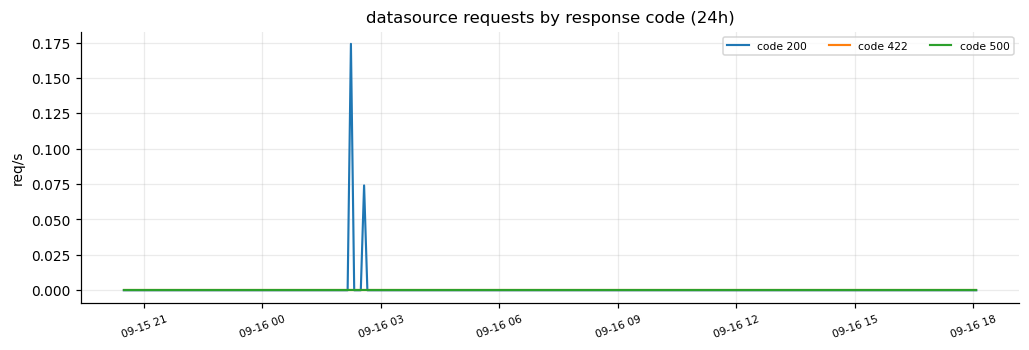

In [5]:
rows = []
for (ds, code), n in sorted(ds_total.items()):
    rows.append({'datasource': ds, 'code': code, f'reqs_{WIN}': n,
                 f'reqs_{RECENT}': ds_recent.get((ds, code), 0.0)})
dst = pd.DataFrame(rows)
if len(dst):
    tot = dst.groupby('datasource')[f'reqs_{WIN}'].sum()
    err = dst[~dst['code'].str.startswith('2')].groupby('datasource')[f'reqs_{WIN}'].sum()
    err_recent = dst[~dst['code'].str.startswith('2')].groupby('datasource')[f'reqs_{RECENT}'].sum()
    summary = pd.DataFrame({'requests': tot, 'errors': err.reindex(tot.index).fillna(0),
                            f'errors_last_{RECENT}': err_recent.reindex(tot.index).fillna(0)})
    summary['error_pct'] = 100 * summary['errors'] / summary['requests'].replace(0, np.nan)
    summary['p99_s'] = pd.Series(ds_latency).reindex(summary.index)
    print(summary.to_string(na_rep='-', float_format=lambda v: f'{v:.2f}'))
    print(f"\nconfigured datasources (by plugin): {ds_configured}")
else:
    print("NO datasource requests recorded in the window at all.")
    print("That is suspicious rather than clean: an idle Grafana still refreshes provisioned")
    print("dashboards. Check the scrape before concluding the datasources are healthy.")

fig, ax = plt.subplots(figsize=(11, 3.2))
for c in f_ds.columns:
    ax.plot(f_ds.index, f_ds[c], lw=1.4, label=f'code {c}')
ax.set_ylabel('req/s'); ax.set_title(f'datasource requests by response code ({WIN})')
ax.legend(fontsize=7, ncol=4); ax.tick_params(axis='x', labelsize=7, rotation=20)
nbc.show(fig)

## Serving -- Grafana's own HTTP surface

The mixin's `GrafanaRequestsFailing` expression is evaluated here directly rather than restated,
so this section and the alert cannot disagree about the arithmetic. Note the label trap baked
into the queries: this metric uses `status_code`, while `grafana_datasource_request_total` above
uses `code` -- the same exporter, two names, and the wrong one returns `success` with zero
series rather than an error.

latency: p50 4ms  p99 117ms  (warn above 10000ms)

no 5xx responses in the last 24h.

GrafanaRequestsFailing expression (alert fires above 50%): 0% on every handler it covers


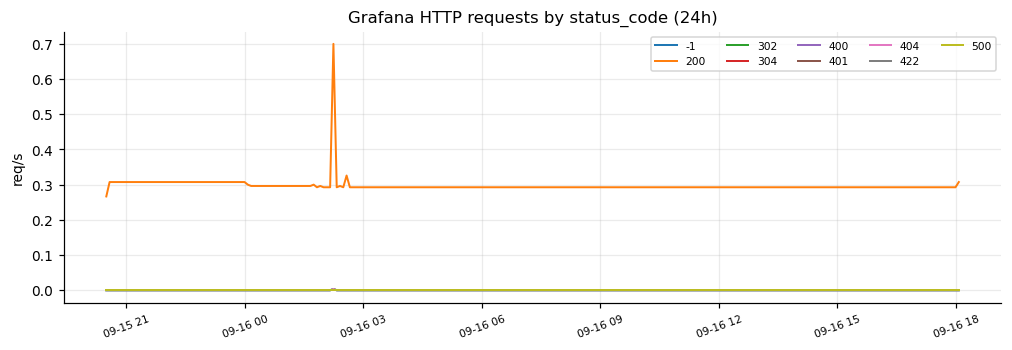

In [6]:
err_rows = [{'handler': hnd, 'status': st, f'n_{WIN}': n,
             f'n_{RECENT}': http_recent.get((hnd, st), 0.0)}
            for (hnd, st), n in http_total.items() if st.startswith('5') and n > 0]
print(f"latency: p50 {lat_p50*1000:.0f}ms  p99 {lat_p99*1000:.0f}ms"
      f"  (warn above {latency_p99_warn_s*1000:.0f}ms)")
if err_rows:
    e = pd.DataFrame(err_rows).sort_values(f'n_{WIN}', ascending=False)
    print(f"\n5xx responses in the last {WIN}:")
    print(e.to_string(index=False, float_format=lambda v: f'{v:.0f}'))
    still = e[e[f'n_{RECENT}'] > 0]
    print(f"\n  still erroring in the last {RECENT}: "
          f"{list(still['handler']) if len(still) else 'none -- historical, not ongoing'}")
else:
    print(f"\nno 5xx responses in the last {WIN}.")

worst = {h: v for h, v in failing.items() if v and not np.isnan(v) and v > 0}
print(f"\nGrafanaRequestsFailing expression (alert fires above {requests_failing_pct}%): "
      + (f"{ {h: round(v, 1) for h, v in worst.items()} }" if worst
         else "0% on every handler it covers"))

fig, ax = plt.subplots(figsize=(11, 3.2))
for c in sorted(f_http.columns):
    ax.plot(f_http.index, f_http[c], lw=1.3, label=c)
ax.set_ylabel('req/s'); ax.set_title(f'Grafana HTTP requests by status_code ({WIN})')
ax.legend(fontsize=7, ncol=5); ax.tick_params(axis='x', labelsize=7, rotation=20)
nbc.show(fig)

## Provisioning drift -- does Grafana have what the sidecars were given?

Both dashboards and datasources arrive by sidecar from labelled ConfigMaps, so the count Grafana
reports and the count Kubernetes holds should track. A gap means the sidecar rejected something
-- the "dashboards not appearing" and "datasources not appearing" entries in the troubleshooting
guide. This is the deliberate two-independent-views cross-check: metric versus kube API.

In [7]:
n_cm_dash = len(cm_dash.get('items', []))
n_cm_ds = len(cm_ds.get('items', []))
n_ds_configured = sum(ds_configured.values()) if ds_configured else float('nan')
print(f"dashboards:  Grafana reports {n_dashboards:.0f}   |  labelled ConfigMaps: {n_cm_dash}"
      f"   {'(kube view unavailable)' if not kube_ok else ''}")
print(f"datasources: Grafana reports {n_ds_configured:.0f}   |  labelled ConfigMaps: {n_cm_ds}")
print(f"users: {n_users:.0f}")
if kube_ok:
    print("\nNote on the dashboard comparison: one ConfigMap can carry more than one dashboard,")
    print("and Grafana counts a few of its own, so exact equality is not the expectation --")
    print("a large or growing gap is. The datasource counts should match closely.")
    folders = {}
    for c in cm_dash.get('items', []):
        f = c['metadata'].get('annotations', {}).get('k8s-sidecar-target-directory', '(none)')
        folders[f.rsplit('/', 1)[-1]] = folders.get(f.rsplit('/', 1)[-1], 0) + 1
    print(f"\ndashboard ConfigMaps by target folder: {dict(sorted(folders.items()))}")

print("\nplugin requests by id/status (the 'plugin errors' troubleshooting entry):")
pl = pd.DataFrame([{'plugin': p, 'status': s, f'n_{WIN}': n} for (p, s), n in plugins.items()])
print(pl.pivot_table(index='plugin', columns='status', values=f'n_{WIN}', fill_value=0)
        .to_string(float_format=lambda v: f'{v:.0f}') if len(pl) else "  (none recorded)")

dashboards:  Grafana reports 87   |  labelled ConfigMaps: 87   
datasources: Grafana reports 4   |  labelled ConfigMaps: 3
users: 1

Note on the dashboard comparison: one ConfigMap can carry more than one dashboard,
and Grafana counts a few of its own, so exact equality is not the expectation --
a large or growing gap is. The datasource counts should match closely.

dashboard ConfigMaps by target folder: {'Alloy': 9, 'Apprise': 1, 'ArgoCD': 3, 'Backpack': 1, 'Bond': 1, 'Cert Manager': 1, 'Cilium': 20, 'CoreDNS': 1, 'Kubernetes': 17, 'Mimir Dashboards': 27, 'Node Exporter': 6}

plugin requests by id/status (the 'plugin errors' troubleshooting entry):
status      error  ok
plugin               
loki            0   0
prometheus      0  28


## Logs and alert state

A wide-angle tail alongside the curated queries: it proves log collection is alive and catches
what the filters dropped. The `grafana` namespace runs three containers -- Grafana plus the
dashboard and datasource sidecars -- and the sidecars are where provisioning failures surface.

In [8]:
print(f"warn/error lines in the last {WIN}: {len(log_bad)}" if logs_ok else "logs UNAVAILABLE")
for ts, s, line in log_bad[:15]:
    print(f"  {ts:%m-%d %H:%M} {s.get('container','?'):<24} {line[:110]}")
if logs_ok and not log_bad:
    print("  (none)")
if logs_ok:
    print(f"\nraw tail (last {min(10, len(log_tail))} of any line in the namespace, newest first):")
    for ts, s, line in log_tail[:10]:
        print(f"  {ts:%m-%d %H:%M} {s.get('container','?'):<24} {line[:105]}")
    by_container = {}
    for _, s, _ in log_tail:
        by_container[s.get('container', '?')] = by_container.get(s.get('container', '?'), 0) + 1
    print(f"\nlines by container in the tail: {by_container}")

print(f"\nGrafana* alerts firing: "
      f"{[(r['metric'].get('alertname'), r['metric'].get('alertstate')) for r in alerts_firing] or 'none'}")

warn/error lines in the last 24h: 9
  09-16 09:53 grafana-sc-dashboard     {"time": "2026-09-16T09:53:48.868415+00:00", "level": "ERROR", "msg": "ProtocolError when calling kubernetes: 
  09-16 09:53 grafana-sc-dashboard     {"time": "2026-09-16T09:53:48.822543+00:00", "level": "ERROR", "msg": "ProtocolError when calling kubernetes: 
  09-16 02:11 grafana                  logger=authn.service t=2026-09-16T02:11:12.198324781Z level=warn msg="Failed to authenticate request" client=a
  09-16 02:11 grafana                  logger=authn.service t=2026-09-16T02:11:01.622923715Z level=warn msg="Failed to authenticate request" client=a
  09-16 02:11 grafana                  logger=authn.service t=2026-09-16T02:11:01.617899533Z level=warn msg="Failed to authenticate request" client=a
  09-15 23:55 grafana-sc-dashboard     {"time": "2026-09-15T23:55:06.813357+00:00", "level": "ERROR", "msg": "Received unknown exception: HTTPSConnec
  09-15 19:39 grafana                  logger=infra.usagestats.c

## Summary

In [9]:
findings = []
if not graf_rules:
    findings.append("grafana-mixin alert rules are NOT loaded in the Mimir ruler -- "
                    "GrafanaRequestsFailing is not being evaluated (expected until the "
                    "grafana-mixin environment is deployed)")
else:
    bad = {k: v for k, v in graf_rules.items() if v[1] != 'ok'}
    if bad:
        findings.append(f"grafana-mixin rules unhealthy in the ruler: {bad}")
for r in alerts_firing:
    findings.append(f"ALERT {r['metric'].get('alertname')} {r['metric'].get('alertstate')}")

if len(dst):
    for dsname, row in summary.iterrows():
        if row['requests'] and row['error_pct'] >= datasource_error_pct:
            ongoing = row[f'errors_last_{RECENT}'] > 0
            findings.append(
                f"datasource {dsname}: {row['errors']:.0f}/{row['requests']:.0f} requests errored "
                f"({row['error_pct']:.1f}%) in {WIN} -- "
                + (f"{row[f'errors_last_{RECENT}']:.0f} in the last {RECENT}, ongoing"
                   if ongoing else f"none in the last {RECENT}, historical not ongoing"))
        if not np.isnan(row['p99_s']) and row['p99_s'] > latency_p99_warn_s:
            findings.append(f"datasource {dsname}: p99 {row['p99_s']:.1f}s > {latency_p99_warn_s}s")
else:
    findings.append("no datasource requests recorded at all -- suspicious empty, verify the scrape")

for h_, v in failing.items():
    if v and not np.isnan(v) and v > requests_failing_pct:
        findings.append(f"handler {h_}: {v:.0f}% 5xx > {requests_failing_pct}% "
                        f"(GrafanaRequestsFailing would fire after 5m)")
if not np.isnan(lat_p99) and lat_p99 > latency_p99_warn_s:
    findings.append(f"HTTP p99 {lat_p99:.1f}s > {latency_p99_warn_s}s -- user-visible sluggishness")
if kube_ok and n_cm_ds and abs(n_ds_configured - n_cm_ds) > 1:
    findings.append(f"datasource drift: Grafana has {n_ds_configured:.0f}, "
                    f"{n_cm_ds} labelled ConfigMaps exist -- sidecar may be rejecting one")
for (p, s), n in plugins.items():
    if s != 'ok' and n > 0:
        ok_n = plugins.get((p, 'ok'), 0)
        findings.append(f"plugin {p}: {n:.0f} {s} vs {ok_n:.0f} ok in {WIN}")
if logs_ok and len(log_bad) > 0:
    # Two recurring classes here are expected rather than faults, and saying so is the
    # difference between a useful count and noise the reader learns to ignore.
    benign = sum(1 for _, _, ln in log_bad if 'usagestats' in ln or 'advisor usage' in ln)
    authfail = sum(1 for _, _, ln in log_bad if 'Failed to authenticate request' in ln)
    rest = len(log_bad) - benign - authfail
    parts = []
    if rest:
        parts.append(f"{rest} unclassified")
    if authfail:
        parts.append(f"{authfail} failed-authentication (the troubleshooting guide's auth entry -- "
                     f"expected if something is probing the ingress, worth a look if not)")
    if benign:
        parts.append(f"{benign} outbound usage-stats failures (Grafana phoning grafana.com; "
                     f"benign where egress is not permitted)")
    findings.append(f"{len(log_bad)} warn/error log lines in {WIN}: " + "; ".join(parts))

print("=== ASSUMPTIONS ===")
print(f"  mimir {mimir_age:.0f}s | grafana scrape {graf_age:.0f}s | Grafana {version}")
print(f"  mixin rules loaded: {list(graf_rules) or 'none'} | logs {'ok' if logs_ok else 'NO'}"
      f" | kube {'ok' if kube_ok else 'NO'}")
print("\n=== FINDINGS ===")
for f_ in findings:
    print(f"  - {f_}")
if not findings:
    print("  none: datasources reachable, no 5xx above threshold, provisioning counts consistent.")

=== ASSUMPTIONS ===
  mimir 0s | grafana scrape 12s | Grafana 12.3.1
  mixin rules loaded: none | logs ok | kube ok

=== FINDINGS ===
  - grafana-mixin alert rules are NOT loaded in the Mimir ruler -- GrafanaRequestsFailing is not being evaluated (expected until the grafana-mixin environment is deployed)
  - 9 warn/error log lines in 24h: 3 unclassified; 3 failed-authentication (the troubleshooting guide's auth entry -- expected if something is probing the ingress, worth a look if not); 3 outbound usage-stats failures (Grafana phoning grafana.com; benign where egress is not permitted)


In [10]:
# --- AGENT-READABLE STATS ---
def _n(v):
    return None if v is None or (isinstance(v, float) and not np.isfinite(v)) else round(float(v), 4)


agent_stats = {
    'notebook': f'{NOTEBOOK}.ipynb', 'run_at': cap.run_at, 'mode': cap.mode,
    'assumptions': {
        'status': 'ok' if (logs_ok and kube_ok and graf_rules) else 'degraded',
        'mimir_age_s': _n(mimir_age), 'grafana_scrape_age_s': _n(graf_age),
        'grafana_version': version,
        'mixin_rules_loaded': {k: {'state': v[0], 'health': v[1]} for k, v in graf_rules.items()},
        'loki_available': logs_ok, 'kube_available': kube_ok,
    },
    'findings': findings,
    'thresholds': {'requests_failing_pct': requests_failing_pct,
                   'source': 'grafana-mixin GrafanaRequestsFailing',
                   'datasource_error_pct': datasource_error_pct, 'chosen': ['datasource_error_pct',
                   'latency_p99_warn_s'], 'latency_p99_warn_s': latency_p99_warn_s},
    'datasources': ({k: {'requests': _n(v['requests']), 'errors': _n(v['errors']),
                         f'errors_last_{RECENT}': _n(v[f'errors_last_{RECENT}']),
                         'error_pct': _n(v['error_pct']), 'p99_s': _n(v['p99_s'])}
                     for k, v in summary.to_dict('index').items()} if len(dst) else {}),
    'http': {'p50_s': _n(lat_p50), 'p99_s': _n(lat_p99),
             'failing_pct_by_handler': {k: _n(v) for k, v in failing.items() if v and not np.isnan(v) and v > 0},
             'errors_5xx': [{'handler': r['handler'], 'status': r['status'],
                             'n': _n(r[f'n_{WIN}']), 'n_recent': _n(r[f'n_{RECENT}'])}
                            for r in err_rows]},
    'provisioning': {'dashboards_grafana': _n(n_dashboards), 'dashboards_configmaps': n_cm_dash,
                     'datasources_grafana': _n(n_ds_configured), 'datasources_configmaps': n_cm_ds,
                     'users': _n(n_users)},
    'plugins': {f'{p}/{s}': _n(n) for (p, s), n in plugins.items()},
    'logs_warn_error_count': len(log_bad) if logs_ok else None,
    'logs_by_container': ({} if not logs_ok else
                          {c: sum(1 for _, s_, _ in log_bad if s_.get('container') == c)
                           for c in {s_.get('container') for _, s_, _ in log_bad}}),
    'alerts_firing': [r['metric'].get('alertname') for r in alerts_firing],
}
print(json.dumps(agent_stats, indent=1))

if output_dir:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    cap.save(out / f'{NOTEBOOK}-capture.json')
    (out / f'{NOTEBOOK}-stats.json').write_text(json.dumps(agent_stats, indent=1))
    print(f"\nwrote {out}/{NOTEBOOK}-capture.json and -stats.json")

{
 "notebook": "grafana-health.ipynb",
 "run_at": "2026-09-16T18:04:19.670003+00:00",
 "mode": "live",
 "assumptions": {
  "status": "degraded",
  "mimir_age_s": 0.47,
  "grafana_scrape_age_s": 11.545,
  "grafana_version": "12.3.1",
  "mixin_rules_loaded": {},
  "loki_available": true,
  "kube_available": true
 },
 "findings": [
  "grafana-mixin alert rules are NOT loaded in the Mimir ruler -- GrafanaRequestsFailing is not being evaluated (expected until the grafana-mixin environment is deployed)",
  "9 warn/error log lines in 24h: 3 unclassified; 3 failed-authentication (the troubleshooting guide's auth entry -- expected if something is probing the ingress, worth a look if not); 3 outbound usage-stats failures (Grafana phoning grafana.com; benign where egress is not permitted)"
 ],
 "thresholds": {
  "requests_failing_pct": 50,
  "source": "grafana-mixin GrafanaRequestsFailing",
  "datasource_error_pct": 1,
  "chosen": [
   "datasource_error_pct",
   "latency_p99_warn_s"
  ],
  "laten